
## Part B: Gaussian Mixture Model Clustering

**What i plan to cover in this notebook:**
- Gaussian Mixture Model (GMM) clustering
- Testing different numbers of components
- Bayesian Information Criterion (BIC)
- Selecting the optimal number of clusters
- GMM clustering (probabilistic)
- GMM visualization
- Comparing K-Means vs GMM



## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42


In [ ]:
## 2. Load Shared Data
shared = pd.read_csv("crime_clustering_shared.csv", index_col="State")
print(shared.shape)
shared.head()


(50, 11)


,Murder,Assault,Rape,Murder_scaled,Assault_scaled,Rape_scaled,PC1,PC2,UrbanPop,KMeans_Cluster,KMeans_Crime_Level
State,,,,,,,,,,,
Alabama,13.2,236,21.2,1.255179,0.790787,-0.003451,1.210191,-0.842277,58,1,Elevated Crime
Alaska,10.0,263,44.5,0.513019,1.118060,2.509424,2.332187,1.539434,48,2,High Crime
Arizona,8.1,294,31.0,0.072361,1.493817,1.053466,1.518593,0.503363,80,2,High Crime
Arkansas,8.8,190,19.5,0.234708,0.233212,-0.186794,0.177776,-0.328029,50,3,Moderate Crime
California,9.0,276,40.6,0.281093,1.275635,2.088814,2.066000,1.285497,91,2,High Crime


In [ ]:
# The 2D PCA-reduced feature space built (same space K-Means was fit on)
pca_components = shared[["PC1", "PC2"]].values
kmeans_labels = shared["KMeans_Cluster"].values

pca_components[:5]


array([[ 1.21019086, -0.84227709],
       [ 2.33218699,  1.5394343 ],
       [ 1.51859328,  0.50336289],
       [ 0.17777619, -0.32802946],
       [ 2.06600019,  1.28549694]])

## 3. Testing Different Numbers of Components

I fit a range of models of the form GaussianMixture's on the same
2D PCA-reduced space, used before for for K-Means, the two clustering algorithms are the same.
approaches are directly comparable.


In [4]:
n_components_range = range(1, 11)
bic_scores = []
aic_scores = []
gmm_models = {}

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=RANDOM_STATE, covariance_type="full")
    gmm.fit(pca_components)
    bic_scores.append(gmm.bic(pca_components))
    aic_scores.append(gmm.aic(pca_components))
    gmm_models[n] = gmm

for n, bic, aic in zip(n_components_range, bic_scores, aic_scores):
    print(f"n_components={n}: BIC={bic:.2f}, AIC={aic:.2f}")


n_components=1: BIC=307.21, AIC=297.65
n_components=2: BIC=293.28, AIC=272.25
n_components=3: BIC=303.99, AIC=271.49
n_components=4: BIC=316.70, AIC=272.72
n_components=5: BIC=319.35, AIC=263.90
n_components=6: BIC=329.70, AIC=262.78
n_components=7: BIC=349.15, AIC=270.76
n_components=8: BIC=326.48, AIC=236.62
n_components=9: BIC=355.60, AIC=254.26
n_components=10: BIC=371.93, AIC=259.12


## 4. Selecting the Optimal Number of Clusters — BIC

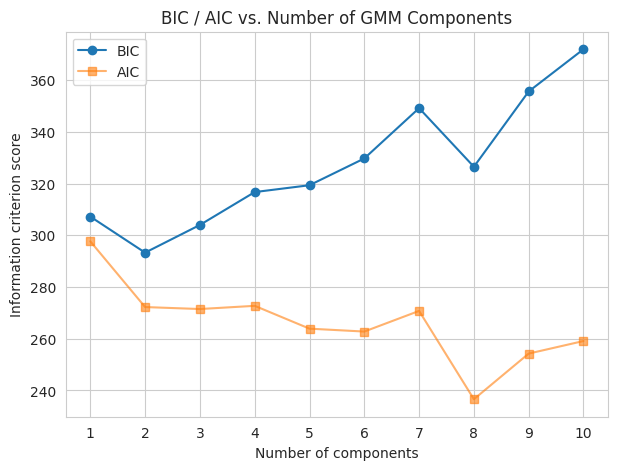

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(list(n_components_range), bic_scores, marker="o", label="BIC")
plt.plot(list(n_components_range), aic_scores, marker="s", label="AIC", alpha=0.6)
plt.xlabel("Number of components")
plt.ylabel("Information criterion score")
plt.title("BIC / AIC vs. Number of GMM Components")
plt.xticks(list(n_components_range))
plt.legend()
plt.show()


In [6]:
best_n = n_components_range[int(np.argmin(bic_scores))]
print(f"Optimal number of components by BIC: {best_n}")


Optimal number of components by BIC: 2


Choosing the number of components: We use the BIC score to help choose the number of components. A lower BIC score indicates a better fit while also taking model complexity into account. We then check the silhouette score for the different numbers of components to see how well the groups are separated. This gives us another way of checking whether the selected number of components makes sense.


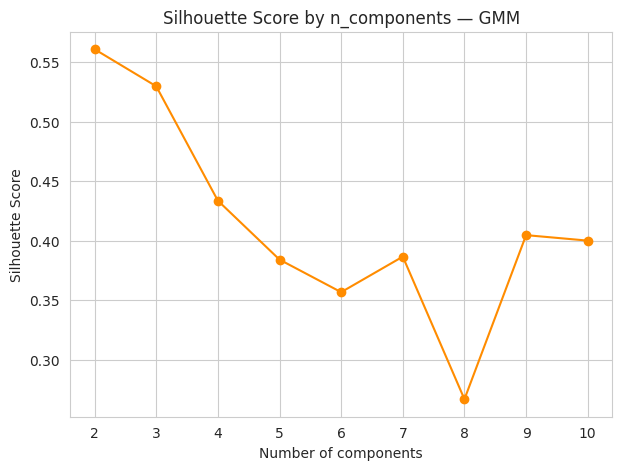

n_components=2: silhouette=0.561
n_components=3: silhouette=0.530
n_components=4: silhouette=0.434
n_components=5: silhouette=0.384
n_components=6: silhouette=0.357
n_components=7: silhouette=0.387
n_components=8: silhouette=0.267
n_components=9: silhouette=0.405
n_components=10: silhouette=0.400


In [7]:
gmm_silhouette_scores = []
sil_n_range = range(2, 11)  # silhouette undefined for n_components=1

for n in sil_n_range:
    labels = gmm_models[n].predict(pca_components)
    gmm_silhouette_scores.append(silhouette_score(pca_components, labels))

plt.figure(figsize=(7, 5))
plt.plot(list(sil_n_range), gmm_silhouette_scores, marker="o", color="darkorange")
plt.xlabel("Number of components")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by n_components — GMM")
plt.xticks(list(sil_n_range))
plt.show()

for n, score in zip(sil_n_range, gmm_silhouette_scores):
    print(f"n_components={n}: silhouette={score:.3f}")


BIC helps us choose the number of Gaussian components that fits the data best, while the silhouette score shows whether those components form clear and separate clusters. If both measures suggest the same number, the choice is easier to justify. If they give different results, then there may not be one obvious answer, so we should use the results to make a reasonable choice and explain why

## 5. GMM Clustering (Probabilistic)

In [8]:
optimal_gmm = gmm_models[best_n]

gmm_labels = optimal_gmm.predict(pca_components)          # hard assignment
gmm_probs = optimal_gmm.predict_proba(pca_components)      # soft/probabilistic assignment

results = shared.copy()
results["GMM_Cluster"] = gmm_labels
for i in range(best_n):
    results[f"GMM_Prob_Cluster{i}"] = gmm_probs[:, i]

results[["PC1", "PC2", "KMeans_Cluster", "GMM_Cluster"]].head()


,PC1,PC2,KMeans_Cluster,GMM_Cluster
State,,,,
Alabama,1.210191,-0.842277,1,1
Alaska,2.332187,1.539434,2,1
Arizona,1.518593,0.503363,2,1
Arkansas,0.177776,-0.328029,3,0
California,2.066000,1.285497,2,1


In [9]:
gmm_final_silhouette = silhouette_score(pca_components, gmm_labels)
kmeans_final_silhouette = silhouette_score(pca_components, kmeans_labels)

print(f"Silhouette score — GMM (n_components={best_n}):    {gmm_final_silhouette:.3f}")
print(f"Silhouette score — K-Means (from Member 3, k={len(np.unique(kmeans_labels))}): {kmeans_final_silhouette:.3f}")


Silhouette score — GMM (n_components=2):    0.561
Silhouette score — K-Means (from Member 3, k=4): 0.464


In [10]:
# Name each GMM cluster by its average crime burden, mirroring Member 3's
# K-Means naming so the two sets of labels are directly comparable for the client
gmm_profile = results.groupby("GMM_Cluster")[["Murder", "Assault", "Rape"]].mean()
gmm_overall_score = gmm_profile.mean(axis=1).sort_values()
gmm_ordered_clusters = gmm_overall_score.index.tolist()

gmm_level_names = ["Low Crime", "Moderate Crime", "Elevated Crime", "High Crime"][:len(gmm_ordered_clusters)]
gmm_name_map = dict(zip(gmm_ordered_clusters, gmm_level_names))

results["GMM_Crime_Level"] = results["GMM_Cluster"].map(gmm_name_map)
results[["GMM_Cluster", "GMM_Crime_Level"]].drop_duplicates().sort_values("GMM_Cluster")


,GMM_Cluster,GMM_Crime_Level
State,,
Arkansas,0,Low Crime
Alabama,1,Moderate Crime


In [11]:
# States GMM is least certain about (max probability close to 1/best_n means high uncertainty)
results["GMM_Confidence"] = gmm_probs.max(axis=1)
results[["GMM_Cluster", "GMM_Confidence"]].sort_values("GMM_Confidence").head(10)


,GMM_Cluster,GMM_Confidence
State,,
Missouri,0,0.883932
Illinois,1,0.894498
Texas,1,0.922961
Tennessee,1,0.923713
New York,1,0.963555
Arizona,1,0.971686
Arkansas,0,0.987282
New Mexico,1,0.994701
Maryland,1,0.994930


## 6. GMM Visualization

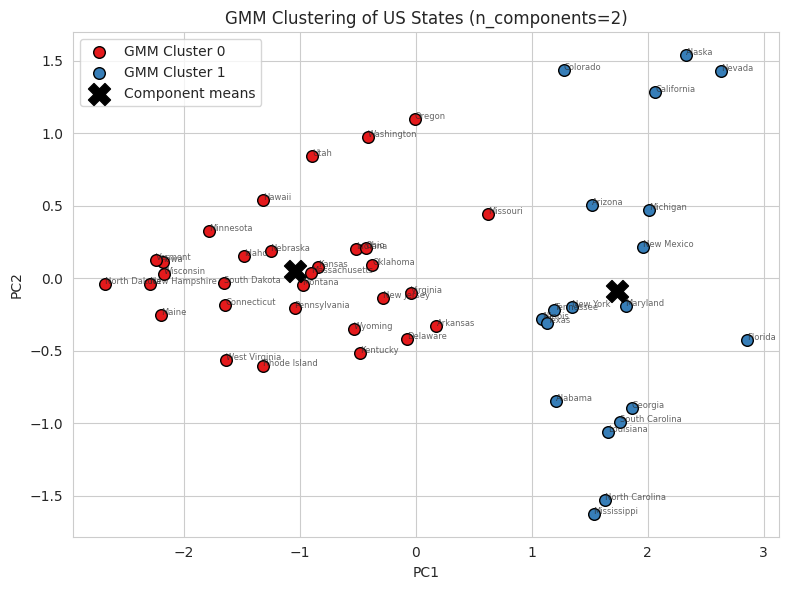

In [12]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set1", best_n)

for cluster_id in range(best_n):
    subset = results[results["GMM_Cluster"] == cluster_id]
    plt.scatter(subset["PC1"], subset["PC2"], s=70, edgecolor="k",
                color=palette[cluster_id], label=f"GMM Cluster {cluster_id}")

means = optimal_gmm.means_
plt.scatter(means[:, 0], means[:, 1], s=250, c="black", marker="X", label="Component means")

for state, row in results.iterrows():
    plt.annotate(state, (row["PC1"], row["PC2"]), fontsize=6, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM Clustering of US States (n_components={best_n})")
plt.legend()
plt.tight_layout()
plt.show()


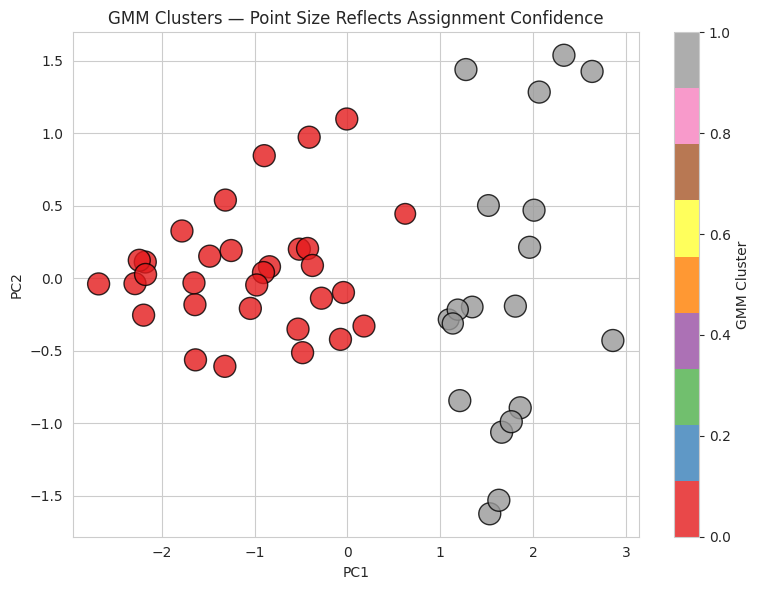

In [13]:
# Visualize assignment uncertainty (soft clustering) via point size/alpha
plt.figure(figsize=(8, 6))
sc = plt.scatter(results["PC1"], results["PC2"], c=results["GMM_Cluster"],
                  s=results["GMM_Confidence"] * 250, cmap="Set1", edgecolor="k", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters — Point Size Reflects Assignment Confidence")
plt.colorbar(sc, label="GMM Cluster")
plt.tight_layout()
plt.show()


## 7. Comparing K-Means vs. GMM

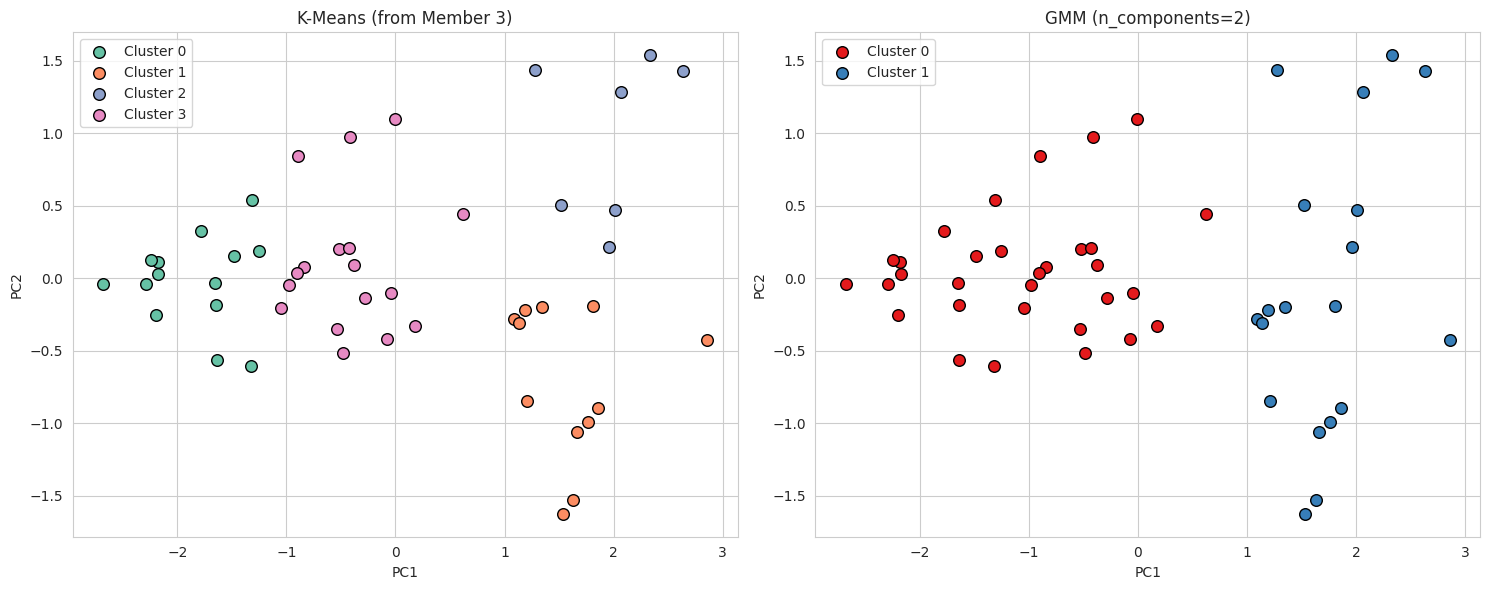

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

kmeans_palette = sns.color_palette("Set2", int(results["KMeans_Cluster"].nunique()))
for cluster_id in sorted(results["KMeans_Cluster"].unique()):
    subset = results[results["KMeans_Cluster"] == cluster_id]
    axes[0].scatter(subset["PC1"], subset["PC2"], s=70, edgecolor="k",
                     color=kmeans_palette[cluster_id], label=f"Cluster {cluster_id}")
axes[0].set_title("K-Means (from Member 3)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend()

gmm_palette = sns.color_palette("Set1", best_n)
for cluster_id in range(best_n):
    subset = results[results["GMM_Cluster"] == cluster_id]
    axes[1].scatter(subset["PC1"], subset["PC2"], s=70, edgecolor="k",
                     color=gmm_palette[cluster_id], label=f"Cluster {cluster_id}")
axes[1].set_title(f"GMM (n_components={best_n})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout()
plt.show()


In [15]:
# Contingency table: how do the two clusterings line up?
contingency = pd.crosstab(results["KMeans_Cluster"], results["GMM_Cluster"],
                           rownames=["K-Means"], colnames=["GMM"])
contingency


GMM,0,1
K-Means,,
0,14,0
1,0,12
2,0,7
3,17,0


In [16]:
ari = adjusted_rand_score(results["KMeans_Cluster"], results["GMM_Cluster"])
print(f"Adjusted Rand Index (K-Means vs GMM agreement): {ari:.3f}")


Adjusted Rand Index (K-Means vs GMM agreement): 0.484


In [17]:
low_confidence_states = results[results["GMM_Confidence"] < 0.7][
    ["KMeans_Cluster", "GMM_Cluster", "GMM_Crime_Level", "GMM_Confidence"]
].sort_values("GMM_Confidence")
print(f"{len(low_confidence_states)} state(s) with ambiguous / borderline GMM cluster assignment (confidence < 0.70):")
low_confidence_states


0 state(s) with ambiguous / borderline GMM cluster assignment (confidence < 0.70):


,KMeans_Cluster,GMM_Cluster,GMM_Crime_Level,GMM_Confidence
State,,,,


**K-Means vs. GMM — interpretation for stakeholders**

How they assign states: K Means places each state into one cluster. GMM is a bit more flexible because it also gives a probability of how strongly a state belongs to a particular cluster. The GMM_Confidence column helps us identify states that are close to another group.

Cluster shape: K Means works best when the clusters are fairly similar in shape and size. GMM can handle clusters with different shapes and sizes, which may be more suitable for the crime data.

How much they agree: The contingency table and Adjusted Rand Index help us compare the results from the two methods. If the ARI is high, it means both methods are finding fairly similar groups. A lower ARI would suggest that some states do not fit clearly into the same groups.

Cluster quality: The silhouette scores give us a way to compare how well separated the clusters are. A higher score means the clusters are generally more distinct from each other.

**Conclusion: Which method should be used?**

K Means is a good choice when each state needs to be placed into one clear group. It is also easier to explain and use when the results need to be presented in a simple way.

GMM is useful when we also want to know how strongly a state belongs to a particular group. This can help identify states that do not clearly fit into one cluster.

Overall, both methods give us a way to identify patterns in the crime data. Comparing their results helps us see whether the groups are reasonably consistent across the two methods.


## 8. Final Combined Results

In [18]:
final_columns = ["Murder", "Assault", "Rape", "UrbanPop", "PC1", "PC2",
                  "KMeans_Cluster", "KMeans_Crime_Level",
                  "GMM_Cluster", "GMM_Crime_Level", "GMM_Confidence"]
final_results = results[final_columns]

final_results.to_csv("crime_clustering_final_results.csv")
print("Saved crime_clustering_final_results.csv with shape:", final_results.shape)
final_results.head(10)


Saved crime_clustering_final_results.csv with shape: (50, 11)


,Murder,Assault,Rape,UrbanPop,PC1,PC2,KMeans_Cluster,KMeans_Crime_Level,GMM_Cluster,GMM_Crime_Level,GMM_Confidence
State,,,,,,,,,,,
Alabama,13.2,236,21.2,58,1.210191,-0.842277,1,Elevated Crime,1,Moderate Crime,0.995248
Alaska,10.0,263,44.5,48,2.332187,1.539434,2,High Crime,1,Moderate Crime,0.999967
Arizona,8.1,294,31.0,80,1.518593,0.503363,2,High Crime,1,Moderate Crime,0.971686
Arkansas,8.8,190,19.5,50,0.177776,-0.328029,3,Moderate Crime,0,Low Crime,0.987282
California,9.0,276,40.6,91,2.066000,1.285497,2,High Crime,1,Moderate Crime,0.999690
Colorado,7.9,204,38.7,78,1.276240,1.440888,2,High Crime,1,Moderate Crime,0.994965
Connecticut,3.3,110,11.1,77,-1.643583,-0.180417,0,Low Crime,0,Low Crime,1.000000
Delaware,5.9,238,15.8,72,-0.075572,-0.419830,3,Moderate Crime,0,Low Crime,0.998154
Florida,15.4,335,31.9,80,2.859470,-0.427616,1,Elevated Crime,1,Moderate Crime,0.999653


crime_clustering_final_results.csv is the final file. It brings together the K Means and GMM results, including the cluster assigned to each state and the GMM confidence score. The results are based on the same standardized and PCA transformed data, making it easier to compare the two methods.


